In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [9]:
class PINN(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(  ##Outputs a u and v, in that order
        nn.Linear(3, 25),   ##3 inputs, x, y, t, and 25 neurons in layer
        nn.Tanh(),
        nn.Linear(25, 25),  ##4 layers
        nn.Tanh(),
        nn.Linear(25, 25),
        nn.Tanh(),
        nn.Linear(25, 25),
        nn.Tanh(),
        nn.Linear(25, 2)  ##These are the outputs
    )

  def forward(self, x):  ##Burgers has 2 velocity components
    return self.net(x)

In [10]:
def gradients(u, x):  ##x y t input, and u output
  return torch.autograd.grad(
      u, x,
      grad_outputs = torch.ones_like(u), create_graph = True
  )[0]

In [11]:
def burgers_pde(model, xyt, nu):
  xyt.requires_grad_(True)

  ##xyt are inputs

  uv = model(xyt)
  u = uv[:, 0: 1]
  v = uv[:, 1: 2]

  grads = gradients(u, xyt)
  u_x, u_y, u_t = grads[:, 0: 1], grads[:, 1: 2], grads[:, 2:3]

  grads_v = gradients(v, xyt)
  v_x, v_y, v_t = grads_v[:, 0: 1], grads_v[:, 1: 2], grads_v[:, 2: 3]

  u_xx = gradients(u_x, xyt)[:, 0: 1]
  u_yy = gradients(u_y, xyt)[:, 1: 2]

  v_xx = gradients(v_x, xyt)[:, 0: 1]
  v_yy = gradients(v_y, xyt)[:, 1: 2]

  f_u = u_t + u * u_x + v * u_y - nu * (u_xx + u_yy)
  f_v = v_t + u * v_t + v * v_y - nu * (v_xx + v_yy)

  return f_u, f_v

In [12]:
Nf = 10000   ##high enough to train a model
x_f = torch.rand(Nf, 1)
y_f = torch.rand(Nf, 1)
z_f = torch.rand(Nf, 1)

X_f = torch.cat([x_f, y_f, z_f], dim = 1)  ##I like tensors :3, so cat. Stack could also work?? Havent tried

In [13]:
Nic = 2000
x_ic = torch.rand(Nic, 1)
y_ic = torch.rand(Nic, 1)
t_ic = torch.zeros_like(x_ic)

##Make u and v match for both models

a1, a2 = 0.5, 0.8
b1, b2 = 0.3, 0.6

u_ic = 0.2 * a1 * np.sin(np.pi * x_ic) + a2 * np.cos(2 * np.pi * y_ic)
v_ic = 0.2 * b1 * np.sin(2 * np.pi * x_ic) + b2 * np.cos(np.pi * y_ic)

X_ic = torch.cat([x_ic, y_ic, t_ic], dim = 1)

/tmp/ipykernel_54198/705280993.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  u_ic = 0.2 * a1 * np.sin(np.pi * x_ic) + a2 * np.cos(2 * np.pi * y_ic)
/tmp/ipykernel_54198/705280993.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v_ic = 0.2 * b1 * np.sin(2 * np.pi * x_ic) + b2 * np.cos(np.pi * y_ic)


In [14]:
N_bc = 2000  ##Boundary conditions
t_bc = torch.rand(N_bc, 1)

y_bc = torch.rand(N_bc, 1)
x0 = torch.zeros_like(y_bc)
x1 = torch.ones_like(y_bc)

X_bc0 = torch.cat([x0, y_bc, t_bc], dim=1)
X_bc1 = torch.cat([x1, y_bc, t_bc], dim=1)

In [15]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

nu = 0.01
epochs = 10000

loss_h = []

for epoch in range(epochs):
  optimizer.zero_grad()

  f_u, f_v = burgers_pde(model, X_f, nu)
  loss_pde = torch.mean(f_u ** 2) + torch.mean(f_v**2)

  uv_ic = model(X_ic)
  loss_ic = torch.mean((uv_ic[:, 0: 1] - u_ic)**2) + torch.mean((uv_ic[:, 1: 2] - u_ic)**2)

  uv0 = model(X_bc0)
  uv1 = model(X_bc1)
  loss_bc = torch.mean((uv0 - uv1)**2)

  loss = loss_pde + loss_ic + loss_bc
  loss.backward()
  optimizer.step()

  loss_h.append(loss.item())

  if epoch %500 == 0:
    print(f"Epoch {epoch}, Loss total: {loss.item():.6f}")

Epoch 0, Loss total: 0.663703
Epoch 500, Loss total: 0.077408
Epoch 1000, Loss total: 0.030370
Epoch 1500, Loss total: 0.018327
Epoch 2000, Loss total: 0.012897
Epoch 2500, Loss total: 0.010409
Epoch 3000, Loss total: 0.008641
Epoch 3500, Loss total: 0.007235
Epoch 4000, Loss total: 0.005849
Epoch 4500, Loss total: 0.004764
Epoch 5000, Loss total: 0.003996
Epoch 5500, Loss total: 0.003497
Epoch 6000, Loss total: 0.003147
Epoch 6500, Loss total: 0.002876
Epoch 7000, Loss total: 0.002654
Epoch 7500, Loss total: 0.002478
Epoch 8000, Loss total: 0.002310
Epoch 8500, Loss total: 0.002347
Epoch 9000, Loss total: 0.002803
Epoch 9500, Loss total: 0.001947


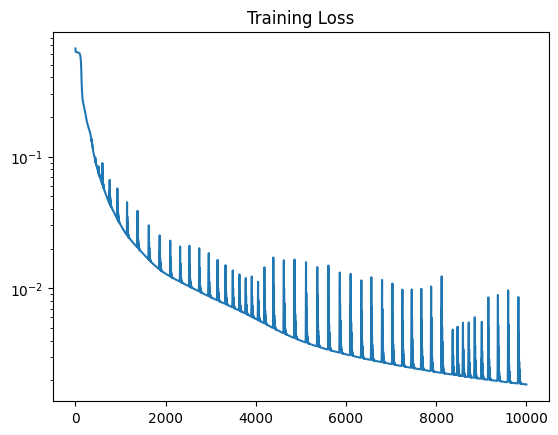

In [16]:
plt.plot(loss_h)
plt.yscale('log')
plt.title("Training Loss")
plt.show()

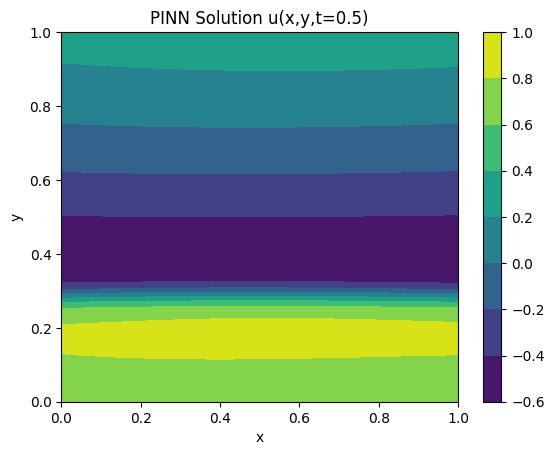

In [17]:
t_val = 0.5   # choose any time you want to inspect
N = 50
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)
XYT = torch.tensor(
    np.stack([
        X.flatten(),
        Y.flatten(),
        t_val * np.ones_like(X.flatten())
    ], axis=1),
    dtype=torch.float32
)
model.eval()
with torch.no_grad():
    uv = model(XYT)

u_pinn = uv[:, 0].cpu().numpy().reshape(N, N)
v_pinn = uv[:, 1].cpu().numpy().reshape(N, N)
plt.figure()
plt.contourf(X, Y, u_pinn)
plt.colorbar()
plt.title(f"PINN Solution u(x,y,t={t_val})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()